# Showcase — Hurricane Ian's track and intensity (Tropycal)

Hurricane **Ian** (September 2022) was one of the costliest US hurricanes, making landfall in southwest Florida as a high-end Category 4. Best-track data (position + intensity every six hours) is curated in HURDAT2/IBTrACS. This notebook uses the earthlens **Tropycal** backend to pull Ian's track and plot its path coloured by wind speed alongside its intensity timeline.

> Runs a live best-track query (needs the `[tropycal]` extra); degrades gracefully otherwise.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens

logger.disable("earthlens"); logger.disable("pyramids")

fixes = None
try:
    fixes = EarthLens(
        data_source="tropycal", variables=["north_atlantic"],
        start="2022-09-23", end="2022-10-01",
        lat_lim=[12.0, 34.0], lon_lim=[-90.0, -70.0],
        source="hurdat", path=tempfile.mkdtemp(),
    ).download(progress_bar=False)
    if fixes is not None and "name" in fixes:
        fixes = fixes[fixes["name"].str.upper() == "IAN"].sort_values("time")
    print(f"{0 if fixes is None else len(fixes)} six-hourly fixes for Ian")
except Exception as exc:  # noqa: BLE001
    print("skipped live query:", exc)

34 six-hourly fixes for Ian


## Track coloured by maximum sustained wind

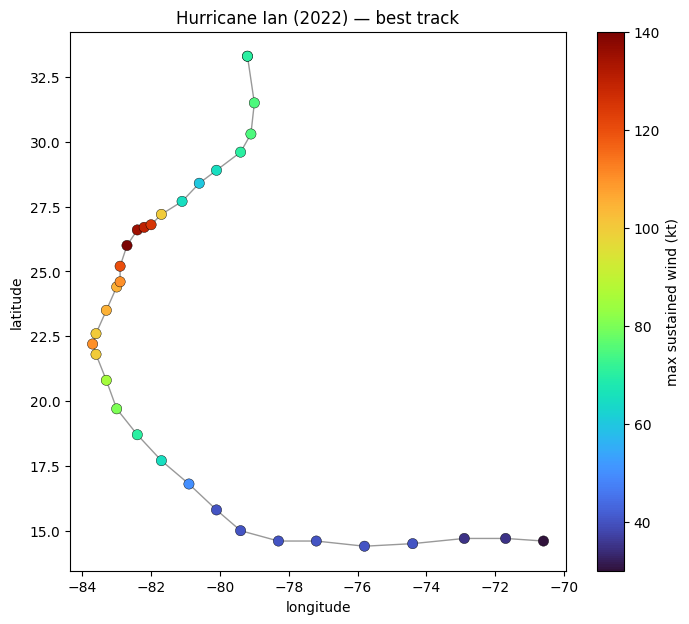

In [2]:
if fixes is not None and len(fixes):
    lon = fixes.geometry.x; lat = fixes.geometry.y
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(lon, lat, "-", color="0.6", lw=1, zorder=1)
    sc = ax.scatter(lon, lat, c=fixes["vmax_kt"], cmap="turbo", s=55, zorder=2,
                    edgecolor="k", linewidth=0.3)
    ax.set(xlabel="longitude", ylabel="latitude", title="Hurricane Ian (2022) — best track")
    fig.colorbar(sc, ax=ax, label="max sustained wind (kt)")
    plt.show()
else:
    print("no track to plot — install earthlens[tropycal] and rerun")

## Intensity timeline

Maximum sustained wind over time, with Saffir–Simpson hurricane thresholds.

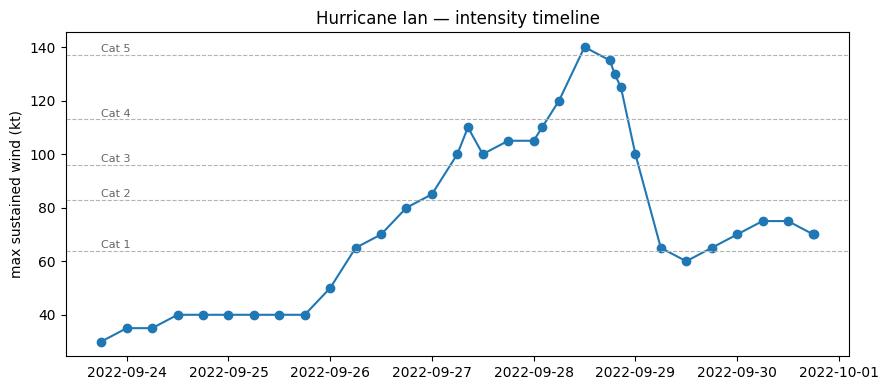

In [3]:
if fixes is not None and len(fixes):
    import pandas as pd
    t = pd.to_datetime(fixes["time"])
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t, fixes["vmax_kt"], "-o", color="tab:blue")
    for kt, lab in [(64, "Cat 1"), (83, "Cat 2"), (96, "Cat 3"), (113, "Cat 4"), (137, "Cat 5")]:
        ax.axhline(kt, color="0.7", ls="--", lw=0.8); ax.text(t.iloc[0], kt + 1, lab, fontsize=8, color="0.4")
    ax.set_ylabel("max sustained wind (kt)"); ax.set_title("Hurricane Ian — intensity timeline")
    plt.tight_layout(); plt.show()
else:
    print("no track")